# 🔍 Credit Card Fraud Detection

> **Data source:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — dataset provided on **Kaggle** by the ULB Machine Learning Group.  
> Contains credit card transactions made by European cardholders in September 2013:  
> **284,807** transactions, of which **492** are fraudulent (0.172% — severe class imbalance).
>
> Features **V1–V28** are obtained via PCA (for confidentiality); the remaining open features are `Time`, `Amount`, and `Class`.

---
### Notebook outline
1. Data loading & basic inspection
2. Exploratory Data Analysis (EDA) + Feature Engineering
3. Data preparation
4. Baseline models: Logistic Regression · Random Forest · Gradient Boosting
5. Baseline evaluation & prediction visualization
6. SMOTE — handling class imbalance
7. Models retrained on SMOTE (LR · RF · GB · LightGBM · XGBoost) — with loss curves
8. Stacking ensemble (SMOTE)
9. Autoencoder & VAE — unsupervised anomaly detection
10. Final comparison — all 11 models (Without SMOTE · With SMOTE · Unsupervised)
11. Temporal split — train on Day 1, test on Day 2 (realistic evaluation)
12. Cost-based threshold & threshold lookup table (FN=$500, FP=$5)
13. Probability calibration — reliability diagram + isotonic calibration
14. SHAP analysis — global feature importance + per-transaction explanations

---
### Key results

| Model | ROC-AUC | PR-AUC |
|---|---|---|
| **XGBoost (SMOTE)** | **0.9842** | **0.8639** |
| LightGBM (SMOTE) | 0.9824 | 0.8546 |
| Stacking (SMOTE) | 0.9838 | 0.8425 |
| Random Forest (SMOTE) | 0.9851 | 0.8231 |
| Autoencoder (unsupervised) | 0.9308 | 0.4913 |
| VAE (unsupervised) | 0.9383 | 0.2939 |

> Best model: XGBoost + SMOTE — **100 out of 123 fraud cases caught** on held-out test set, **8 false alarms**.

In [ ]:
# Standard library
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sklearn: model selection & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Sklearn: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

# Sklearn: metrics
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report,
    confusion_matrix, roc_curve, brier_score_loss,
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Gradient boosting
import lightgbm as lgb
from xgboost import XGBClassifier

# PyTorch (Autoencoder / VAE)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# SHAP
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Data Loading

In [2]:
df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)
print("\nFraud rate (baseline PR-AUC):", round(df["Class"].mean(), 6))
print("\nClass counts:")
print(df["Class"].value_counts())

display(df.head())

Shape: (284807, 31)

Fraud rate (baseline PR-AUC): 0.001727

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("=" * 50)
print("Missing values:")
print(df.isnull().sum().sum(), "total NaN")
print("\nData types:")
print(df.dtypes.value_counts())

Missing values:
0 total NaN

Data types:
float64    30
int64       1
Name: count, dtype: int64


## 2. EDA & Feature Engineering

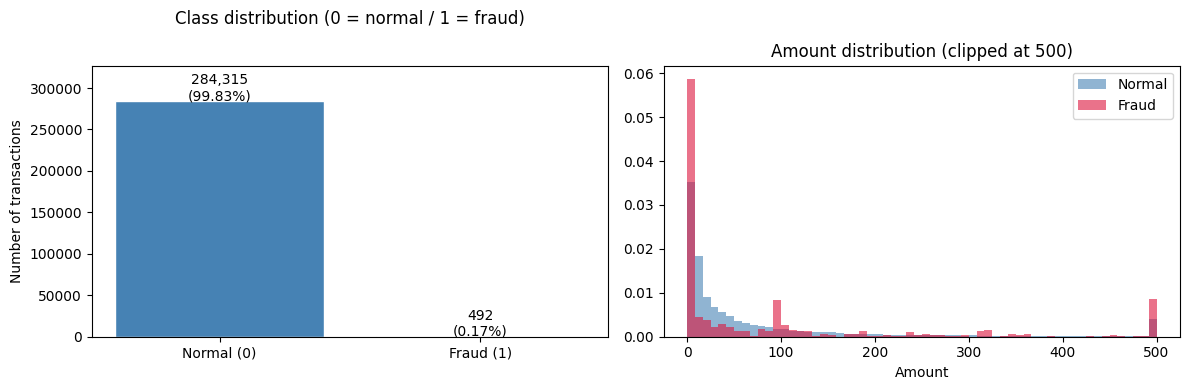

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = df["Class"].value_counts()
axes[0].bar(["Normal (0)", "Fraud (1)"], counts.values,
            color=["steelblue", "crimson"], edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}\n({v/len(df)*100:.2f}%)",
                 ha="center", fontsize=10)
axes[0].set_title("Class distribution (0 = normal / 1 = fraud)", pad=30)
axes[0].set_ylabel("Number of transactions")
axes[0].set_ylim(0, counts.max() * 1.15)

# Amount distribution
axes[1].hist(df[df["Class"] == 0]["Amount"].clip(upper=500), bins=60,
             alpha=0.6, color="steelblue", label="Normal", density=True)
axes[1].hist(df[df["Class"] == 1]["Amount"].clip(upper=500), bins=60,
             alpha=0.6, color="crimson", label="Fraud", density=True)
axes[1].set_title("Amount distribution (clipped at 500)")
axes[1].set_xlabel("Amount")
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Feature Engineering

# Time to datetime-derived features
START_TS = pd.Timestamp("2013-09-01 00:00:00")
df["ts"]   = START_TS + pd.to_timedelta(df["Time"], unit="s")
df["hour"] = df["ts"].dt.hour
df["dow"]  = df["ts"].dt.dayofweek

# Log-Amount (compresses right tail)
df["Amount_log"] = np.log1p(df["Amount"])

# Squared Amount (adds nonlinearity for LR)
df["Amount_sq"] = df["Amount"] ** 2

print("New features added:", ["hour", "dow", "Amount_log", "Amount_sq"])
display(df[["Time", "ts", "hour", "dow", "Amount", "Amount_log"]].head())

New features added: ['hour', 'dow', 'Amount_log', 'Amount_sq']


,Time,ts,hour,dow,Amount,Amount_log
0,0.0,2013-09-01 00:00:00,0,6,149.62,5.014760
1,0.0,2013-09-01 00:00:00,0,6,2.69,1.305626
2,1.0,2013-09-01 00:00:01,0,6,378.66,5.939276
3,1.0,2013-09-01 00:00:01,0,6,123.50,4.824306
4,2.0,2013-09-01 00:00:02,0,6,69.99,4.262539


In [6]:
train_idx, test_idx = train_test_split(
    df.index, test_size=0.25, random_state=SEED, stratify=df["Class"]
)
df_train = df.loc[train_idx].copy()
df_test  = df.loc[test_idx].copy()

print(f"Train: {len(df_train):,}  |  Test: {len(df_test):,}")
print(f"Fraud rate train: {df_train['Class'].mean():.6f}")
print(f"Fraud rate test:  {df_test['Class'].mean():.6f}")

Train: 213,605  |  Test: 71,202
Fraud rate train: 0.001727
Fraud rate test:  0.001727


In [7]:
# Hour-level aggregation (fit on train only, then merge into test)
hour_stats = (
    df_train.groupby("hour", as_index=False)
            .agg(
                n_hour=("Amount", "size"),
                amount_mean_hour=("Amount", "mean"),
                amount_median_hour=("Amount", "median"),
                fraud_rate_hour=("Class", "mean"),
            )
            .sort_values("hour")
            .reset_index(drop=True)
)

# Rolling mean smoothing
hour_stats["amount_mean_roll3"] = (
    hour_stats["amount_mean_hour"].rolling(window=3, min_periods=1).mean()
)

df_train = df_train.merge(hour_stats, on="hour", how="left")
df_test  = df_test.merge(hour_stats,  on="hour", how="left")

# Fill rare hours in test with train median
agg_cols = ["n_hour", "amount_mean_hour", "amount_median_hour",
            "fraud_rate_hour", "amount_mean_roll3"]
for c in agg_cols:
    df_test[c] = df_test[c].fillna(df_train[c].median())

# Fraud rate by hour
fig = px.line(hour_stats, x="hour", y="fraud_rate_hour",
              title="Train: fraud rate by hour of day",
              labels={"fraud_rate_hour": "Fraud rate", "hour": "Hour"})
fig.update_traces(line_color="crimson")
fig.show()

fig2 = px.line(hour_stats, x="hour",
               y=["amount_mean_hour", "amount_mean_roll3"],
               title="Train: mean Amount by hour (rolling-3 smoothing)")
fig2.show()

## 3. Data Preparation

In [8]:
DROP = ["Class", "ts", "Time"]  # drop non-numeric / raw Time

X_train = df_train.drop(columns=DROP).select_dtypes(include=[np.number]).copy()
y_train = df_train["Class"].astype(int)

X_test  = df_test.drop(columns=DROP).select_dtypes(include=[np.number]).copy()
y_test  = df_test["Class"].astype(int)

# Align feature sets
shared_cols = [c for c in X_train.columns if c in X_test.columns]
X_train, X_test = X_train[shared_cols], X_test[shared_cols]

# Fill remaining NaN with median
for col in X_train.columns:
    if X_train[col].isna().any():
        med = X_train[col].median()
        X_train[col] = X_train[col].fillna(med)
        X_test[col]  = X_test[col].fillna(med)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Features:", list(X_train.columns))

X_train: (213605, 38) | X_test: (71202, 38)
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'hour', 'dow', 'Amount_log', 'Amount_sq', 'n_hour', 'amount_mean_hour', 'amount_median_hour', 'fraud_rate_hour', 'amount_mean_roll3']


## 4. Model Training

In [9]:
# Logistic Regression
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED))
])
lr_pipeline.fit(X_train, y_train)

score_lr = lr_pipeline.decision_function(X_test)
if roc_auc_score(y_test, score_lr) < 0.5:
    score_lr = -score_lr

roc_lr = roc_auc_score(y_test, score_lr)
ap_lr  = average_precision_score(y_test, score_lr)
print(f"Logistic Regression  ->  ROC-AUC: {roc_lr:.4f}  |  PR-AUC: {ap_lr:.4f}")

Logistic Regression  ->  ROC-AUC: 0.9772  |  PR-AUC: 0.7212


In [10]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=12,
    class_weight="balanced", random_state=SEED, n_jobs=-1
)
rf_model.fit(X_train, y_train)

score_rf = rf_model.predict_proba(X_test)[:, 1]
roc_rf = roc_auc_score(y_test, score_rf)
ap_rf  = average_precision_score(y_test, score_rf)
print(f"Random Forest        ->  ROC-AUC: {roc_rf:.4f}  |  PR-AUC: {ap_rf:.4f}")

Random Forest        ->  ROC-AUC: 0.9773  |  PR-AUC: 0.8149


In [11]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)
gb_model.fit(X_train, y_train)

score_gb = gb_model.predict_proba(X_test)[:, 1]
roc_gb = roc_auc_score(y_test, score_gb)
ap_gb  = average_precision_score(y_test, score_gb)
print(f"Gradient Boosting    ->  ROC-AUC: {roc_gb:.4f}  |  PR-AUC: {ap_gb:.4f}")

Gradient Boosting    ->  ROC-AUC: 0.8611  |  PR-AUC: 0.5495


## 5. Evaluation & Prediction Visualization

In [12]:
# Summary metrics table
results = pd.DataFrame({
    "Model":    ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC-AUC": [roc_lr, roc_rf, roc_gb],
    "PR-AUC":  [ap_lr,  ap_rf,  ap_gb],
})
results = results.sort_values("PR-AUC", ascending=False).reset_index(drop=True)
results[["ROC-AUC", "PR-AUC"]] = results[["ROC-AUC", "PR-AUC"]].round(4)
display(results)

,Model,ROC-AUC,PR-AUC
0,Random Forest,0.9773,0.8149
1,Logistic Regression,0.9772,0.7212
2,Gradient Boosting,0.8611,0.5495


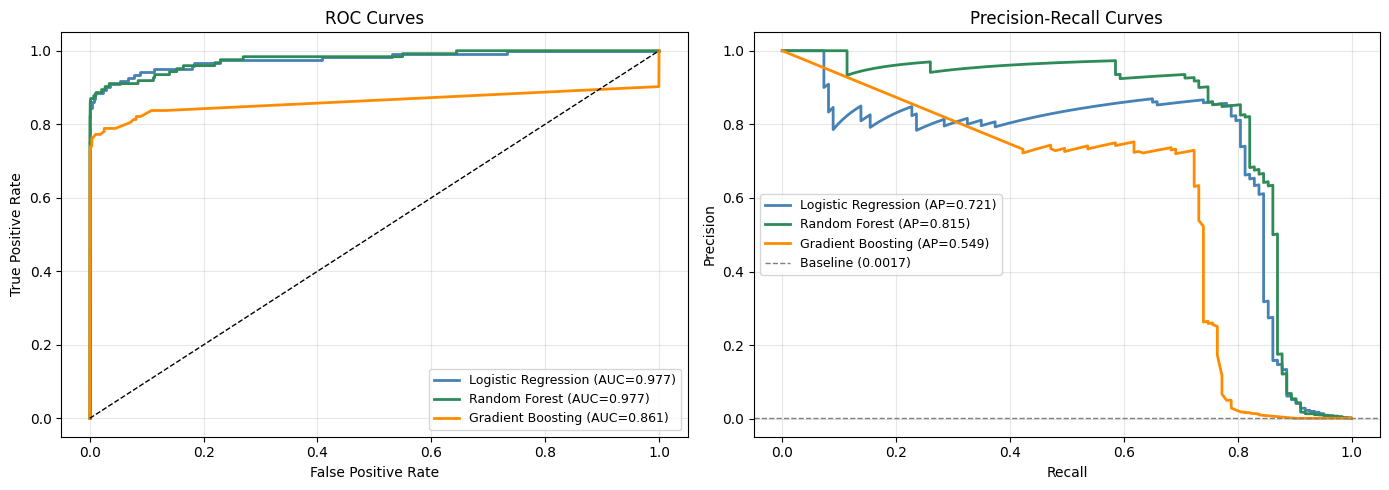

In [13]:
# ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

MODELS = [
    ("Logistic Regression", score_lr, "steelblue"),
    ("Random Forest",       score_rf, "seagreen"),
    ("Gradient Boosting",   score_gb, "darkorange"),
]

# ROC
for name, score, color in MODELS:
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=2)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# PR
baseline = y_test.mean()
for name, score, color in MODELS:
    prec, rec, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color, lw=2)
axes[1].axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline ({baseline:.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
def best_threshold(y_true, scores, metric="f1"):
    """Find threshold that maximises F1."""
    prec, rec, thr = precision_recall_curve(y_true, scores)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    best_i = int(np.argmax(f1))
    return float(thr[best_i]), f1[best_i], prec[best_i], rec[best_i]

for name, score, _ in MODELS:
    thr, f1, p, r = best_threshold(y_test, score)
    print(f"{name:<22}  thr={thr:.4f}  F1={f1:.4f}  P={p:.4f}  R={r:.4f}")

Logistic Regression     thr=15.6400  F1=0.8186  P=0.8509  R=0.7886
Random Forest           thr=0.4417  F1=0.8285  P=0.8534  R=0.8049
Gradient Boosting       thr=0.5291  F1=0.7265  P=0.7295  R=0.7236


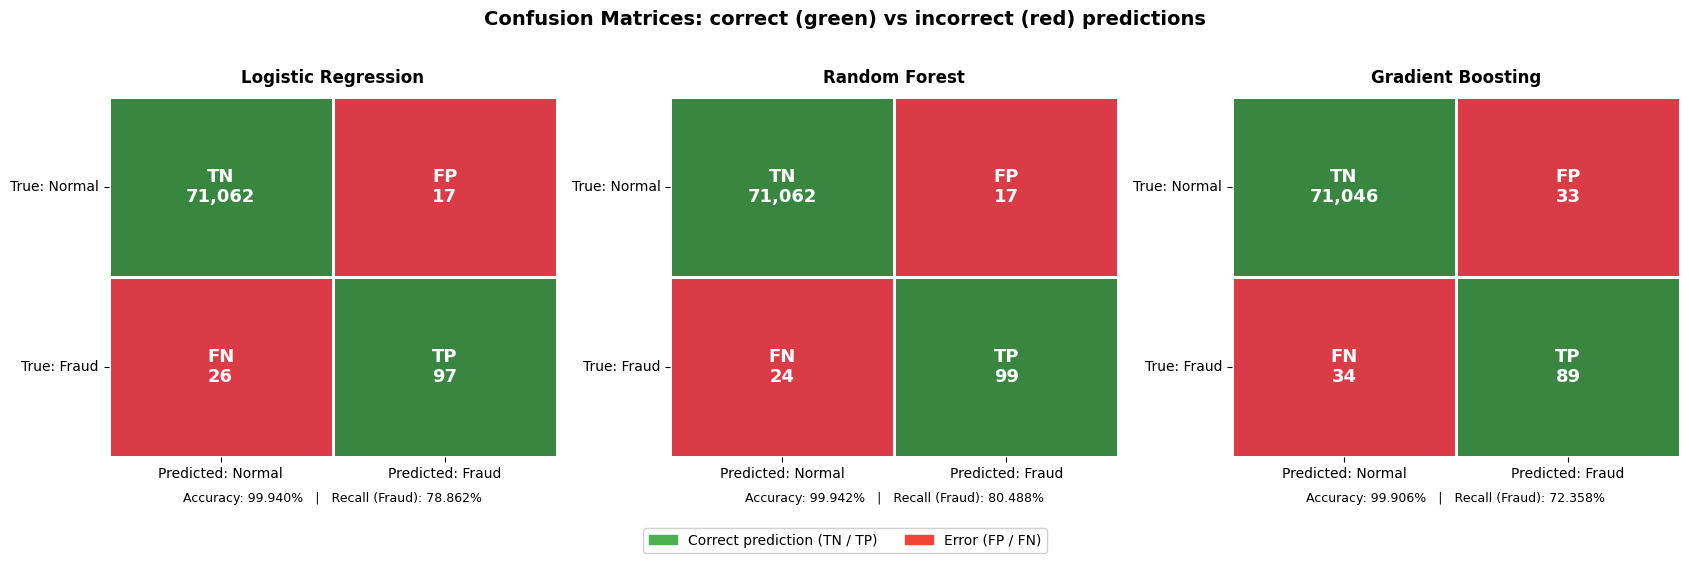

In [15]:
#  Correct vs incorrect predictions — confusion matrices
#  Green = correct (TN / TP),  Red = error (FP / FN)

def plot_confusion(ax, y_true, scores, title):
    thr, _, _, _ = best_threshold(y_true, scores)
    pred = (scores >= thr).astype(int)
    cm = confusion_matrix(y_true, pred)

    labels = np.array([
        [f"TN\n{cm[0,0]:,}", f"FP\n{cm[0,1]:,}"],
        [f"FN\n{cm[1,0]:,}", f"TP\n{cm[1,1]:,}"]
    ])

    # Color mask: correct (TN/TP) = green, errors (FP/FN) = red
    color_map = np.array([[1, 0], [0, 1]])
    cmap = sns.diverging_palette(10, 130, as_cmap=True)

    sns.heatmap(
        color_map, ax=ax,
        annot=labels, fmt="",
        cmap=cmap, vmin=0, vmax=1,
        linewidths=2, linecolor="white",
        cbar=False,
        annot_kws={"size": 13, "weight": "bold"}
    )
    ax.set_xticklabels(["Predicted: Normal", "Predicted: Fraud"], fontsize=10)
    ax.set_yticklabels(["True: Normal", "True: Fraud"], fontsize=10, rotation=0)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
    recall_fraud = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
    ax.set_xlabel(
        f"Accuracy: {accuracy:.3%}   |   Recall (Fraud): {recall_fraud:.3%}",
        fontsize=9, labelpad=8
    )


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Confusion Matrices: correct (green) vs incorrect (red) predictions",
             fontsize=14, fontweight="bold", y=1.02)

plot_confusion(axes[0], y_test, score_lr, "Logistic Regression")
plot_confusion(axes[1], y_test, score_rf, "Random Forest")
plot_confusion(axes[2], y_test, score_gb, "Gradient Boosting")

# Legend
correct_patch = mpatches.Patch(color="#4CAF50", label="Correct prediction (TN / TP)")
wrong_patch   = mpatches.Patch(color="#F44336", label="Error (FP / FN)")
fig.legend(handles=[correct_patch, wrong_patch],
           loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.08), fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

In [16]:
#  Scatter: Amount vs Score — color = prediction status

# Pick best model by PR-AUC
best_name, best_score, best_color = max(
    MODELS, key=lambda x: average_precision_score(y_test, x[1])
)
best_thr = best_threshold(y_test, best_score)[0]
best_pred = (best_score >= best_thr).astype(int)

status = []
for true, pred in zip(y_test, best_pred):
    if true == 0 and pred == 0:
        status.append("True Negative")
    elif true == 1 and pred == 1:
        status.append("True Positive")
    elif true == 0 and pred == 1:
        status.append("False Positive")
    else:
        status.append("False Negative")

scatter_df = pd.DataFrame({
    "Amount":     df_test["Amount"].values,
    "Score":      best_score,
    "True label": y_test.values,
    "Status":     status,
})

color_map_scatter = {
    "True Negative":  "#2196F3",  # blue
    "True Positive":  "#4CAF50",  # green
    "False Positive": "#FF9800",  # orange
    "False Negative": "#F44336",  # red
}

fig = px.scatter(
    scatter_df, x="Amount", y="Score",
    color="Status",
    color_discrete_map=color_map_scatter,
    opacity=0.6,
    title=f"{best_name} — prediction distribution (Amount vs Score)",
    labels={"Score": "Fraud probability", "Amount": "Transaction amount"},
    hover_data=["True label"],
    log_x=True,
)
fig.add_hline(y=best_thr, line_dash="dash", line_color="black",
              annotation_text=f"Threshold = {best_thr:.3f}")
fig.update_layout(legend_title_text="Prediction status")
fig.show()

print("\nStatus breakdown:")
print(pd.Series(status).value_counts())


Status breakdown:
True Negative     71062
True Positive        99
False Negative       24
False Positive       17
Name: count, dtype: int64


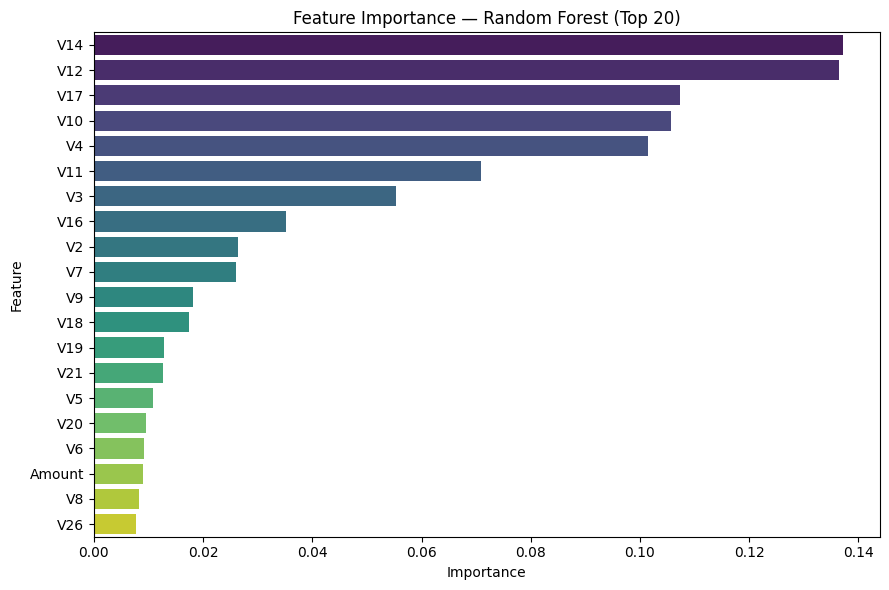

In [17]:
#  Feature Importance (best tree-based model)

best_tree = rf_model if roc_rf >= roc_gb else gb_model
tree_name = "Random Forest" if roc_rf >= roc_gb else "Gradient Boosting"

imp_df = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importance": best_tree.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(9, 6))
sns.barplot(data=imp_df, y="Feature", x="Importance",
            palette="viridis", orient="h")
plt.title(f"Feature Importance — {tree_name} (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [18]:
#  Detailed classification report — best model

print(f"Classification Report — {best_name}")
print("=" * 55)
print(classification_report(y_test, best_pred, digits=4,
                             target_names=["Normal", "Fraud"]))

Classification Report — Random Forest
              precision    recall  f1-score   support

      Normal     0.9997    0.9998    0.9997     71079
       Fraud     0.8534    0.8049    0.8285       123

    accuracy                         0.9994     71202
   macro avg     0.9266    0.9023    0.9141     71202
weighted avg     0.9994    0.9994    0.9994     71202



## 6. SMOTE — Handling Class Imbalance

> Applied **only to the training set**. Test set is untouched — we evaluate all models on the same real distribution.

Before SMOTE  —  train: 213,605
  Normal: 213,236  |  Fraud: 369

After SMOTE  —  train: 426,472
  Normal: 213,236  |  Fraud: 213,236


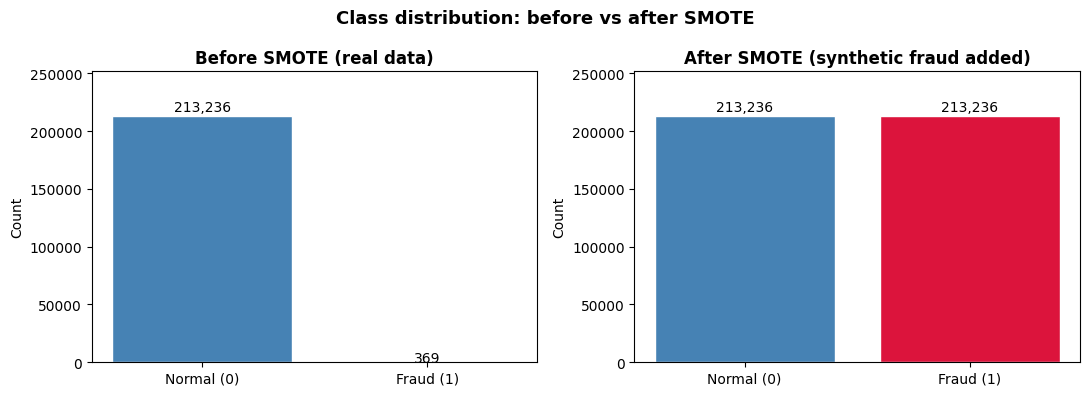


SMOTE train split: 383,824  |  val split: 42,648


In [ ]:
print(f'Before SMOTE  —  train: {len(X_train):,}')
print(f'  Normal: {(y_train==0).sum():,}  |  Fraud: {(y_train==1).sum():,}')

sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE  —  train: {len(X_train_sm):,}')
print(f'  Normal: {(y_train_sm==0).sum():,}  |  Fraud: {(y_train_sm==1).sum():,}')

# Visualise balance before / after
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y, title in zip(axes,
                         [y_train, y_train_sm],
                         ['Before SMOTE (real data)', 'After SMOTE (synthetic fraud added)']):
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(['Normal (0)', 'Fraud (1)'], counts.values,
           color=['steelblue', 'crimson'], edgecolor='white')
    for i, v in enumerate(counts.values):
        ax.text(i, v * 1.02, f'{v:,}', ha='center', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.18)
plt.suptitle('Class distribution: before vs after SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Hold-out validation split from SMOTE data (for loss curves)
from sklearn.model_selection import train_test_split as tts
X_sm_tr, X_sm_val, y_sm_tr, y_sm_val = tts(
    X_train_sm, y_train_sm, test_size=0.1, random_state=SEED, stratify=y_train_sm
)
print(f'\nSMOTE train split: {len(X_sm_tr):,}  |  val split: {len(X_sm_val):,}')

## 7. Models Retrained on SMOTE Data

All five models are trained on the balanced SMOTE dataset.  
**No `class_weight` needed** — SMOTE already balanced the classes.  
Loss curves are shown for gradient-based models (LightGBM, XGBoost).

In [ ]:
#  Logistic Regression (SMOTE)

lr_sm = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=3000, random_state=SEED))  # no class_weight
])
lr_sm.fit(X_train_sm, y_train_sm)
score_lr_sm = lr_sm.decision_function(X_test)
if roc_auc_score(y_test, score_lr_sm) < 0.5:
    score_lr_sm = -score_lr_sm

print(f'LR  (SMOTE)  ->  ROC-AUC: {roc_auc_score(y_test, score_lr_sm):.4f}'  
      f'  |  PR-AUC: {average_precision_score(y_test, score_lr_sm):.4f}')

LR  (SMOTE)  ->  ROC-AUC: 0.9759  |  PR-AUC: 0.7218


In [ ]:
# Random Forest (SMOTE)

rf_sm = RandomForestClassifier(
    n_estimators=200, max_depth=12,
    random_state=SEED, n_jobs=-1  # no class_weight
)
rf_sm.fit(X_train_sm, y_train_sm)
score_rf_sm = rf_sm.predict_proba(X_test)[:, 1]

print(f'RF  (SMOTE)  ->  ROC-AUC: {roc_auc_score(y_test, score_rf_sm):.4f}'  
      f'  |  PR-AUC: {average_precision_score(y_test, score_rf_sm):.4f}')

RF  (SMOTE)  ->  ROC-AUC: 0.9851  |  PR-AUC: 0.8231


In [ ]:
# Gradient Boosting (SMOTE)

gb_sm = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)
gb_sm.fit(X_train_sm, y_train_sm)
score_gb_sm = gb_sm.predict_proba(X_test)[:, 1]

print(f'GB  (SMOTE)  ->  ROC-AUC: {roc_auc_score(y_test, score_gb_sm):.4f}'  
      f'  |  PR-AUC: {average_precision_score(y_test, score_gb_sm):.4f}')

GB  (SMOTE)  ->  ROC-AUC: 0.9786  |  PR-AUC: 0.7698


[100]	training's binary_logloss: 0.0147117	valid_1's binary_logloss: 0.0156149
[200]	training's binary_logloss: 0.00281362	valid_1's binary_logloss: 0.00362285
[300]	training's binary_logloss: 0.000699472	valid_1's binary_logloss: 0.00141297
[400]	training's binary_logloss: 0.000180365	valid_1's binary_logloss: 0.000845918
[500]	training's binary_logloss: 5.43109e-05	valid_1's binary_logloss: 0.00072354
LightGBM (SMOTE)  ->  ROC-AUC: 0.9824  |  PR-AUC: 0.8546


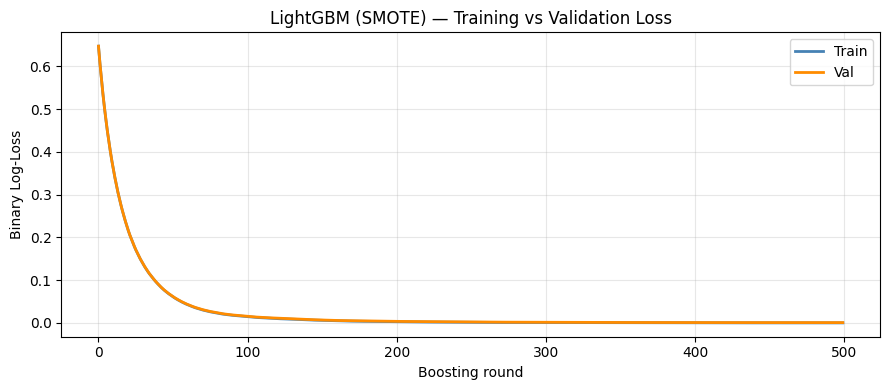

In [ ]:
# LightGBM (SMOTE) + loss curve

lgb_sm = lgb.LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, verbose=-1
)
evals_lgbm = {}
lgb_sm.fit(
    X_sm_tr, y_sm_tr,
    eval_set=[(X_sm_tr, y_sm_tr), (X_sm_val, y_sm_val)],
    eval_metric='binary_logloss',
    callbacks=[lgb.log_evaluation(period=100),
               lgb.record_evaluation(evals_lgbm)]
)
score_lgbm_sm = lgb_sm.predict_proba(X_test)[:, 1]

print(f'LightGBM (SMOTE)  ->  ROC-AUC: {roc_auc_score(y_test, score_lgbm_sm):.4f}'  
      f'  |  PR-AUC: {average_precision_score(y_test, score_lgbm_sm):.4f}')

# Loss curve
plt.figure(figsize=(9, 4))
plt.plot(evals_lgbm['training']['binary_logloss'], label='Train', color='steelblue', lw=2)
plt.plot(evals_lgbm['valid_1']['binary_logloss'],  label='Val',   color='darkorange', lw=2)
plt.xlabel('Boosting round')
plt.ylabel('Binary Log-Loss')
plt.title('LightGBM (SMOTE) — Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

XGBoost  (SMOTE)  ->  ROC-AUC: 0.9842  |  PR-AUC: 0.8639


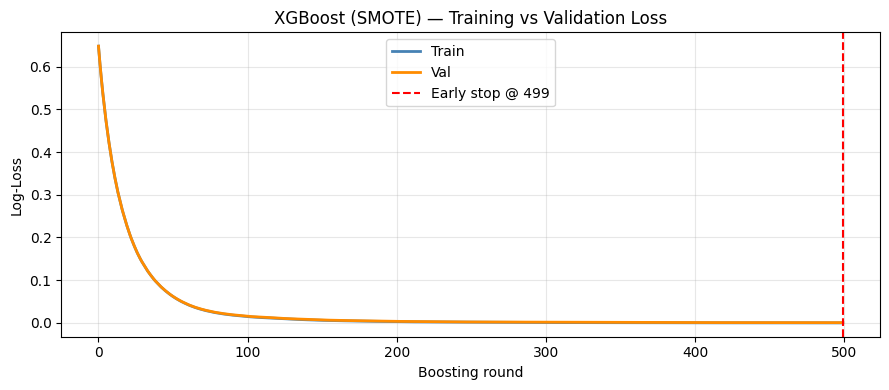

In [ ]:
# XGBoost (SMOTE) + loss curve

xgb_sm = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=30,
    random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_sm.fit(
    X_sm_tr, y_sm_tr,
    eval_set=[(X_sm_tr, y_sm_tr), (X_sm_val, y_sm_val)],
    verbose=False
)
score_xgb_sm = xgb_sm.predict_proba(X_test)[:, 1]

print(f'XGBoost  (SMOTE)  ->  ROC-AUC: {roc_auc_score(y_test, score_xgb_sm):.4f}'  
      f'  |  PR-AUC: {average_precision_score(y_test, score_xgb_sm):.4f}')

# Loss curve
xgb_res = xgb_sm.evals_result()
best_rd  = xgb_sm.best_iteration

plt.figure(figsize=(9, 4))
plt.plot(xgb_res['validation_0']['logloss'], label='Train', color='steelblue', lw=2)
plt.plot(xgb_res['validation_1']['logloss'], label='Val',   color='darkorange', lw=2)
plt.axvline(best_rd, color='red', ls='--', lw=1.5, label=f'Early stop @ {best_rd}')
plt.xlabel('Boosting round')
plt.ylabel('Log-Loss')
plt.title('XGBoost (SMOTE) — Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Stacking Ensemble (SMOTE)

> Meta-learner is trained on out-of-fold predictions from 4 base models via 3-fold CV.  
> All base models use the SMOTE-balanced training set.

In [ ]:
base_estimators = [
    ('lr',   Pipeline([('scaler', StandardScaler()),
                       ('lr', LogisticRegression(max_iter=3000, random_state=SEED))])),
    ('rf',   RandomForestClassifier(n_estimators=100, max_depth=12,
                                    random_state=SEED, n_jobs=-1)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                 random_state=SEED, n_jobs=-1, verbose=-1)),
    ('xgb',  XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                            random_state=SEED, n_jobs=-1, verbosity=0)),
]

stack_sm = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    cv=3, stack_method='predict_proba', n_jobs=-1
)

print('Training stacking ensemble (3-fold CV)...')
stack_sm.fit(X_train_sm, y_train_sm)

score_stack_sm = stack_sm.predict_proba(X_test)[:, 1]
print(f'\nStacking (SMOTE)  ->  ROC-AUC: {roc_auc_score(y_test, score_stack_sm):.4f}'  
      f'  |  PR-AUC: {average_precision_score(y_test, score_stack_sm):.4f}')

Training stacking ensemble (3-fold CV)...

Stacking (SMOTE)  ->  ROC-AUC: 0.9838  |  PR-AUC: 0.8425


## 9. Autoencoder — Anomaly Detection

> Trained **only on normal transactions** from the original (non-SMOTE) train set.  
> Fraud is detected by high reconstruction error — the model never saw fraud during training.  
> This is an **unsupervised** approach: no labels used during training.

Device: cuda
  Epoch  10/60  MSE: 0.392386
  Epoch  20/60  MSE: 0.329670
  Epoch  30/60  MSE: 0.301018
  Epoch  40/60  MSE: 0.281944
  Epoch  50/60  MSE: 0.266337
  Epoch  60/60  MSE: 0.255328


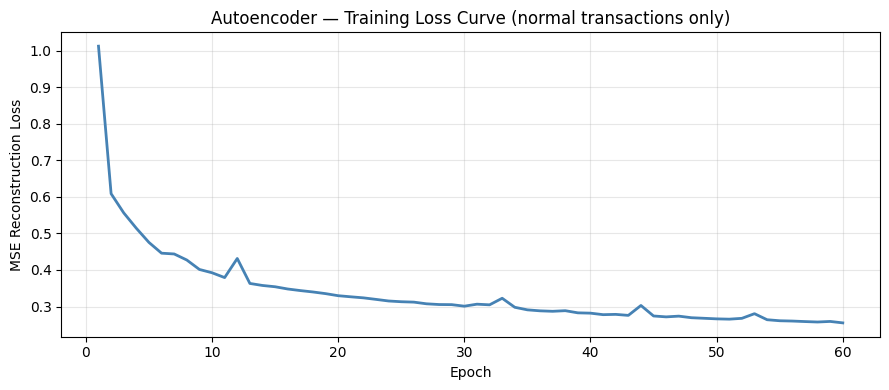

In [ ]:
# Scale using only normal train samples
scaler_ae    = StandardScaler()
X_ae_train   = scaler_ae.fit_transform(X_train[y_train == 0])
X_ae_test    = scaler_ae.transform(X_test)

IN_DIM = X_ae_train.shape[1]
EPOCHS, BATCH, LR_AE = 60, 512, 1e-3

train_t = torch.FloatTensor(X_ae_train)
test_t  = torch.FloatTensor(X_ae_test)
loader  = DataLoader(TensorDataset(train_t, train_t), batch_size=BATCH, shuffle=True)

class Autoencoder(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8),  nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),  nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, d),
        )
    def forward(self, x): return self.decoder(self.encoder(x))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
ae = Autoencoder(IN_DIM).to(device)
opt  = torch.optim.Adam(ae.parameters(), lr=LR_AE, weight_decay=1e-5)
loss_fn = nn.MSELoss()

ae_losses = []
ae.train()
for epoch in range(1, EPOCHS + 1):
    ep_loss = sum(loss_fn(ae(xb.to(device)), xb.to(device)).item() * len(xb)
                  for xb, _ in loader) / len(train_t)
    ae_losses.append(ep_loss)
    # manual backward pass
    for xb, _ in loader:
        xb = xb.to(device)
        loss = loss_fn(ae(xb), xb)
        opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/{EPOCHS}  MSE: {ep_loss:.6f}')

# Loss curve
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), ae_losses, color='steelblue', lw=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Reconstruction Loss')
plt.title('Autoencoder — Training Loss Curve (normal transactions only)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

  Epoch  10/60  VAE Loss: 28.7662
  Epoch  20/60  VAE Loss: 26.8609
  Epoch  30/60  VAE Loss: 25.3646
  Epoch  40/60  VAE Loss: 24.6952
  Epoch  50/60  VAE Loss: 24.8828
  Epoch  60/60  VAE Loss: 24.0870


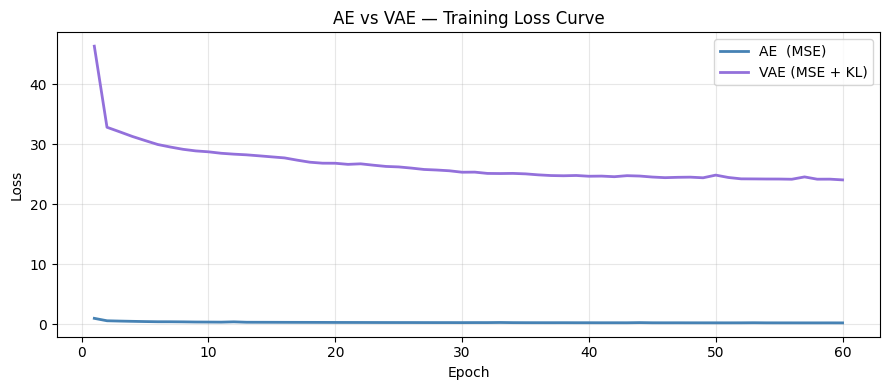

In [30]:
class VAE(nn.Module):
    def __init__(self, d, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU()
        )
        self.fc_mu  = nn.Linear(16, latent_dim)
        self.fc_var = nn.Linear(16, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, d)
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, log_var = self.fc_mu(h), self.fc_var(h)
        z = self.reparameterize(mu, log_var)
        return self.decoder(z), mu, log_var

def vae_loss(recon, x, mu, log_var, beta=1.0):
    mse = nn.functional.mse_loss(recon, x, reduction='sum')
    kl  = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return (mse + beta * kl) / len(x)

EPOCHS_VAE = 60
vae = VAE(IN_DIM, latent_dim=8).to(device)
opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-3, weight_decay=1e-5)

vae_losses = []
vae.train()
for epoch in range(1, EPOCHS_VAE + 1):
    ep_loss = 0.0
    for xb, _ in loader:
        xb = xb.to(device)
        recon, mu, log_var = vae(xb)
        loss = vae_loss(recon, xb, mu, log_var, beta=1.0)
        opt_vae.zero_grad(); loss.backward(); opt_vae.step()
        ep_loss += loss.item() * len(xb)
    vae_losses.append(ep_loss / len(train_t))
    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/{EPOCHS_VAE}  VAE Loss: {ep_loss/len(train_t):.4f}')

# Loss curve: AE vs VAE
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS + 1),     ae_losses,  label='AE  (MSE)',       color='steelblue', lw=2)
plt.plot(range(1, EPOCHS_VAE + 1), vae_losses, label='VAE (MSE + KL)',  color='mediumpurple', lw=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('AE vs VAE — Training Loss Curve')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Autoencoder  ->  ROC-AUC: 0.9424  |  PR-AUC: 0.5722


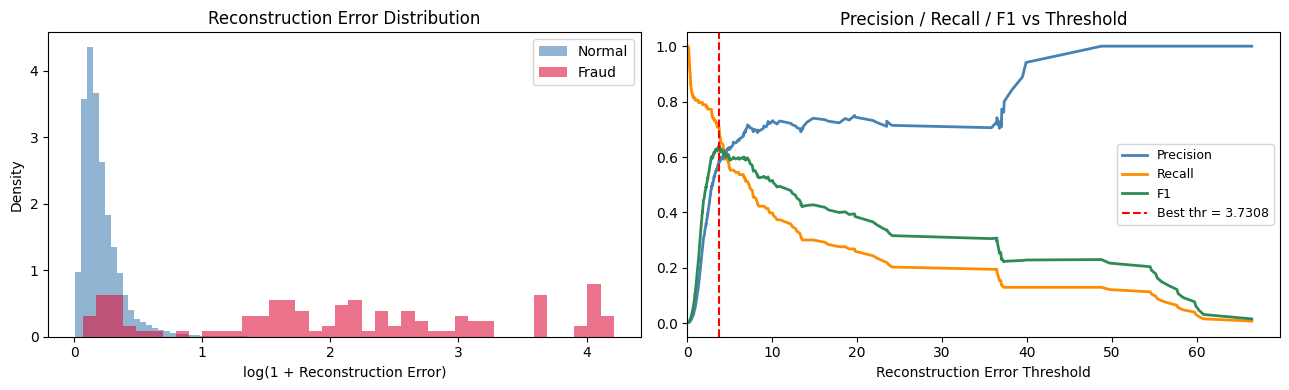

In [31]:
# Reconstruction error = anomaly score
ae.eval()
with torch.no_grad():
    recon = ae(test_t.to(device)).cpu().numpy()
score_ae = np.mean((X_ae_test - recon) ** 2, axis=1)

roc_ae = roc_auc_score(y_test, score_ae)
ap_ae  = average_precision_score(y_test, score_ae)
print(f'Autoencoder  ->  ROC-AUC: {roc_ae:.4f}  |  PR-AUC: {ap_ae:.4f}')

# Error distribution + Precision/Recall/F1 vs threshold
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.log1p(score_ae[y_test == 0]), bins=80, alpha=0.6,
             color='steelblue', label='Normal', density=True)
axes[0].hist(np.log1p(score_ae[y_test == 1]), bins=40, alpha=0.6,
             color='crimson',  label='Fraud',  density=True)
axes[0].set_xlabel('log(1 + Reconstruction Error)')
axes[0].set_ylabel('Density')
axes[0].set_title('Reconstruction Error Distribution')
axes[0].legend()

prec_ae, rec_ae, thr_ae = precision_recall_curve(y_test, score_ae)
f1_ae = 2 * prec_ae[:-1] * rec_ae[:-1] / (prec_ae[:-1] + rec_ae[:-1] + 1e-12)
best_thr_ae = thr_ae[np.argmax(f1_ae)]
axes[1].plot(thr_ae, prec_ae[:-1], label='Precision', color='steelblue', lw=2)
axes[1].plot(thr_ae, rec_ae[:-1],  label='Recall',    color='darkorange', lw=2)
axes[1].plot(thr_ae, f1_ae,        label='F1',        color='seagreen',   lw=2)
axes[1].axvline(best_thr_ae, color='red', ls='--', lw=1.5,
                label=f'Best thr = {best_thr_ae:.4f}')
axes[1].set_xlabel('Reconstruction Error Threshold')
axes[1].set_title('Precision / Recall / F1 vs Threshold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(left=0)
plt.tight_layout()
plt.show()

VAE  ->  ROC-AUC: 0.9344  |  PR-AUC: 0.3483


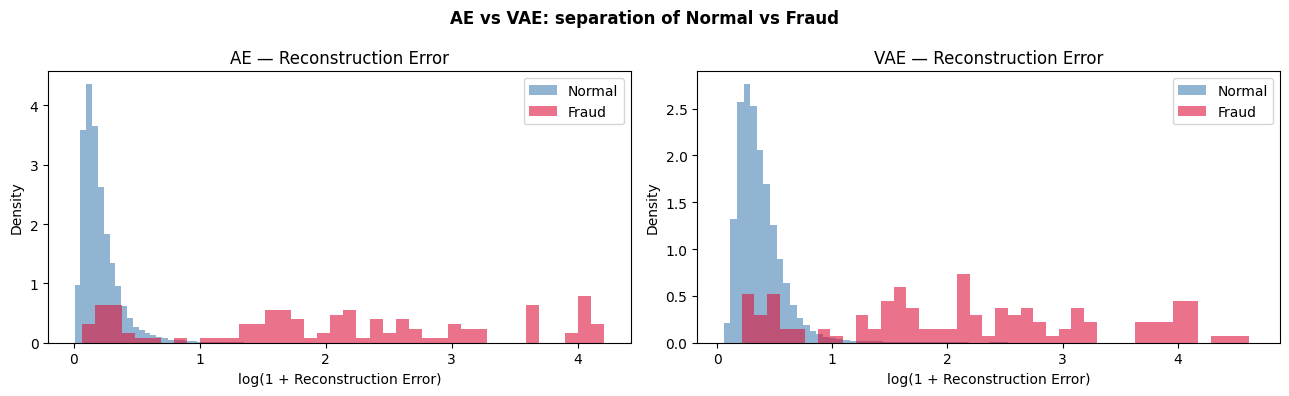

In [32]:
vae.eval()
with torch.no_grad():
    recon_vae, mu_vae, _ = vae(test_t.to(device))
    recon_vae = recon_vae.cpu().numpy()

score_vae = np.mean((X_ae_test - recon_vae) ** 2, axis=1)

roc_vae = roc_auc_score(y_test, score_vae)
ap_vae  = average_precision_score(y_test, score_vae)
print(f'VAE  ->  ROC-AUC: {roc_vae:.4f}  |  PR-AUC: {ap_vae:.4f}')

# AE vs VAE: ошибка реконструкции по классам
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, score, title in zip(axes,
                              [score_ae, score_vae],
                              ['AE — Reconstruction Error', 'VAE — Reconstruction Error']):
    ax.hist(np.log1p(score[y_test == 0]), bins=80, alpha=0.6,
            color='steelblue', label='Normal', density=True)
    ax.hist(np.log1p(score[y_test == 1]), bins=40, alpha=0.6,
            color='crimson', label='Fraud', density=True)
    ax.set_xlabel('log(1 + Reconstruction Error)')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()
plt.suptitle('AE vs VAE: separation of Normal vs Fraud', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Final Comparison: Without SMOTE vs With SMOTE

> All models are evaluated on the **same test set** (real data, never touched by SMOTE).  
> Autoencoder is shown separately — it is unsupervised and not directly comparable.

In [34]:
# Build summary table
WITHOUT_SMOTE = [
    ('LR  (no SMOTE)',  score_lr,  'steelblue'),
    ('RF  (no SMOTE)',  score_rf,  'seagreen'),
    ('GB  (no SMOTE)',  score_gb,  'darkorange'),
]
WITH_SMOTE = [
    ('LR  (SMOTE)',      score_lr_sm,    'steelblue'),
    ('RF  (SMOTE)',      score_rf_sm,    'seagreen'),
    ('GB  (SMOTE)',      score_gb_sm,    'darkorange'),
    ('LightGBM (SMOTE)', score_lgbm_sm,  'mediumpurple'),
    ('XGBoost  (SMOTE)', score_xgb_sm,   'tomato'),
    ('Stacking (SMOTE)', score_stack_sm, 'gold'),
]
AUTOENCODER = [
    ('Autoencoder (unsupervised)', score_ae,  'teal'),
    ('VAE         (unsupervised)', score_vae, 'mediumseagreen'),
]

def make_summary(models, group):
    rows = []
    for name, score, _ in models:
        rows.append({
            'Group': group, 'Model': name,
            'ROC-AUC': round(roc_auc_score(y_test, score), 4),
            'PR-AUC':  round(average_precision_score(y_test, score), 4),
        })
    return pd.DataFrame(rows)

summary_all = pd.concat([
    make_summary(WITHOUT_SMOTE, 'Without SMOTE'),
    make_summary(WITH_SMOTE,    'With SMOTE'),
    make_summary(AUTOENCODER,   'Unsupervised'),
], ignore_index=True).sort_values(['Group', 'PR-AUC'], ascending=[True, False])

display(summary_all.reset_index(drop=True))

,Group,Model,ROC-AUC,PR-AUC
0,Unsupervised,Autoencoder (unsupervised),0.9424,0.5722
1,Unsupervised,VAE (unsupervised),0.9344,0.3483
2,With SMOTE,XGBoost (SMOTE),0.9842,0.8639
3,With SMOTE,LightGBM (SMOTE),0.9824,0.8546
4,With SMOTE,Stacking (SMOTE),0.9838,0.8425
5,With SMOTE,RF (SMOTE),0.9851,0.8231
6,With SMOTE,GB (SMOTE),0.9786,0.7698
7,With SMOTE,LR (SMOTE),0.9759,0.7218
8,Without SMOTE,RF (no SMOTE),0.9773,0.8149
9,Without SMOTE,LR (no SMOTE),0.9772,0.7212


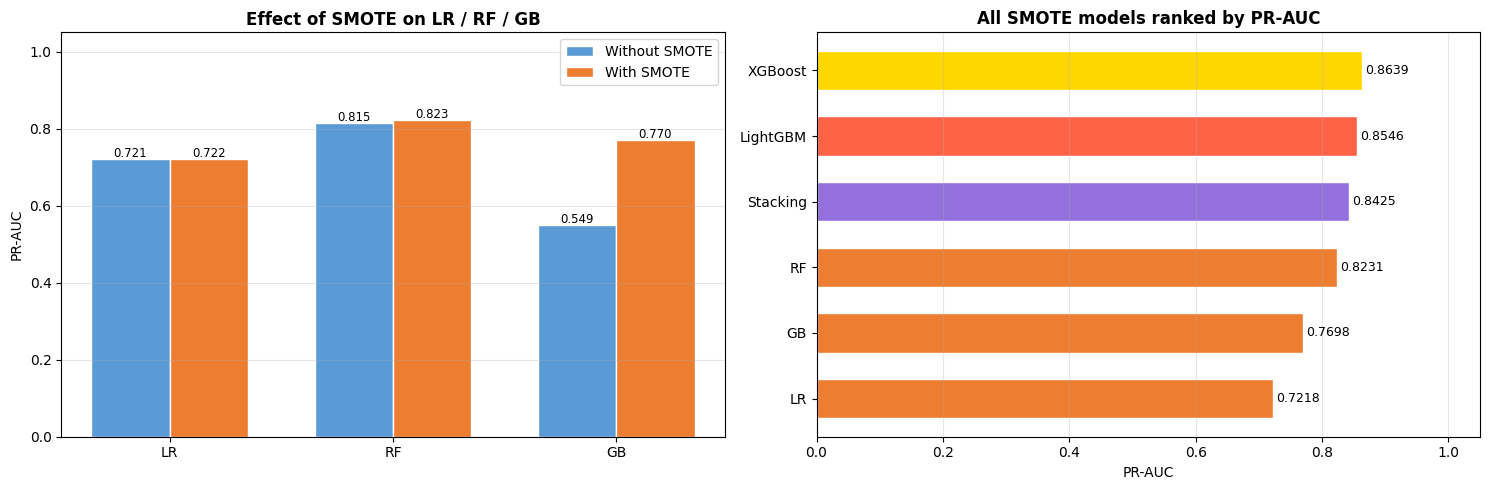

In [ ]:
# Side-by-side bar chart: PR-AUC grouped by model family

base_names  = ['LR', 'RF', 'GB']
smote_extra = ['LightGBM', 'XGBoost', 'Stacking']

pr_no  = {r['Model'].split('(')[0].strip(): r['PR-AUC']
          for _, r in summary_all[summary_all['Group']=='Without SMOTE'].iterrows()}
pr_sm  = {r['Model'].split('(')[0].strip(): r['PR-AUC']
          for _, r in summary_all[summary_all['Group']=='With SMOTE'].iterrows()}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: same 3 models, two bars each
x = np.arange(len(base_names))
w = 0.35
axes[0].bar(x - w/2, [pr_no.get(n, 0) for n in base_names],
            width=w, label='Without SMOTE', color='#5B9BD5', edgecolor='white')
axes[0].bar(x + w/2, [pr_sm.get(n, 0) for n in base_names],
            width=w, label='With SMOTE',    color='#ED7D31', edgecolor='white')
for i, name in enumerate(base_names):
    for offset, d in [(-w/2, pr_no), (+w/2, pr_sm)]:
        v = d.get(name, 0)
        axes[0].text(i + offset, v + 0.005, f'{v:.3f}', ha='center', fontsize=8.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(base_names)
axes[0].set_ylabel('PR-AUC')
axes[0].set_title('Effect of SMOTE on LR / RF / GB', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Right: all SMOTE models ranked
smote_rows = summary_all[summary_all['Group']=='With SMOTE'].sort_values('PR-AUC')
bars = axes[1].barh(smote_rows['Model'].str.split('(').str[0].str.strip(),
                    smote_rows['PR-AUC'],
                    color=['#ED7D31','#ED7D31','#ED7D31','mediumpurple','tomato','gold'],
                    edgecolor='white', height=0.6)
for bar, v in zip(bars, smote_rows['PR-AUC']):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)
axes[1].set_xlabel('PR-AUC')
axes[1].set_title('All SMOTE models ranked by PR-AUC', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

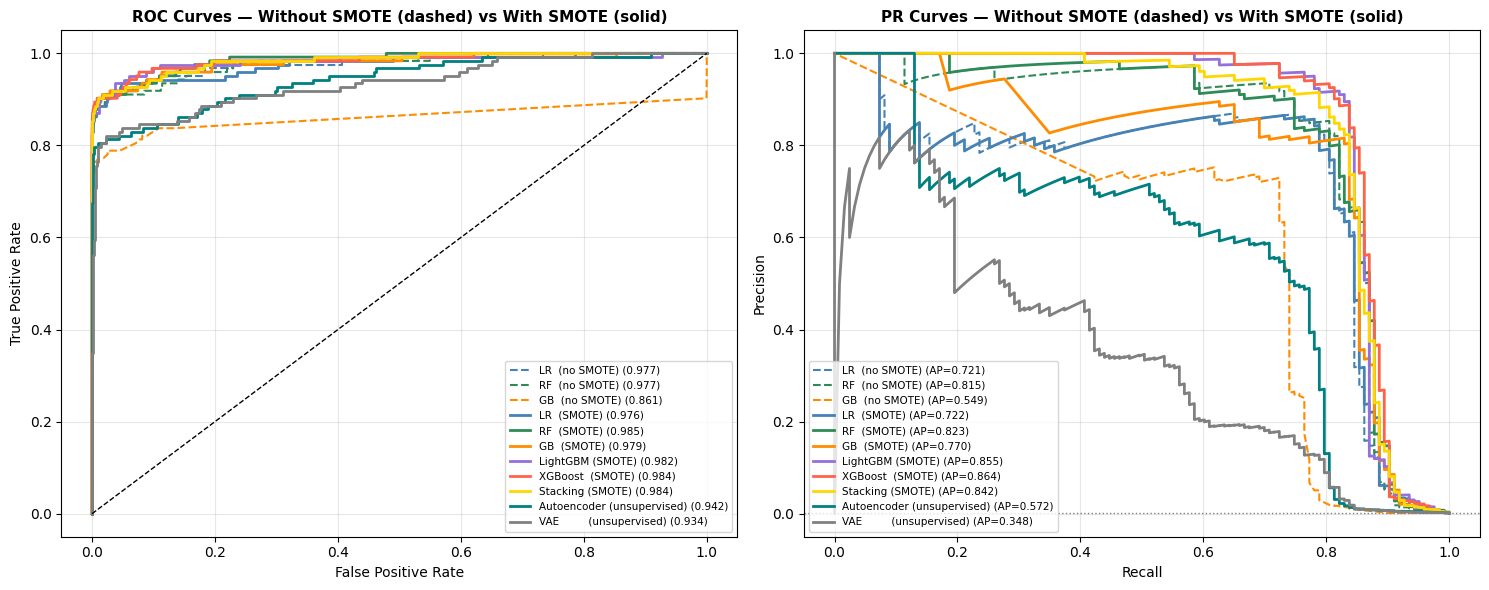

In [36]:
# ROC + PR curves: Without SMOTE (dashed) vs With SMOTE (solid)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = {'LR': 'steelblue', 'RF': 'seagreen', 'GB': 'darkorange',
           'LightGBM': 'mediumpurple', 'XGBoost': 'tomato',
           'Stacking': 'gold', 'Autoencoder': 'teal'}

for name, score, _ in WITHOUT_SMOTE + WITH_SMOTE + AUTOENCODER:
    short = name.split('(')[0].strip()
    color = palette.get(short, 'gray')
    ls    = '--' if 'no SMOTE' in name else '-'
    lw    = 1.5 if 'no SMOTE' in name else 2

    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    axes[0].plot(fpr, tpr, label=f'{name} ({auc:.3f})', color=color, ls=ls, lw=lw)

    prec, rec, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, ls=ls, lw=lw)

for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7.5, loc='best')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Without SMOTE (dashed) vs With SMOTE (solid)',
                  fontsize=11, fontweight='bold')
axes[1].axhline(y_test.mean(), color='gray', ls=':', lw=1)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves — Without SMOTE (dashed) vs With SMOTE (solid)',
                  fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

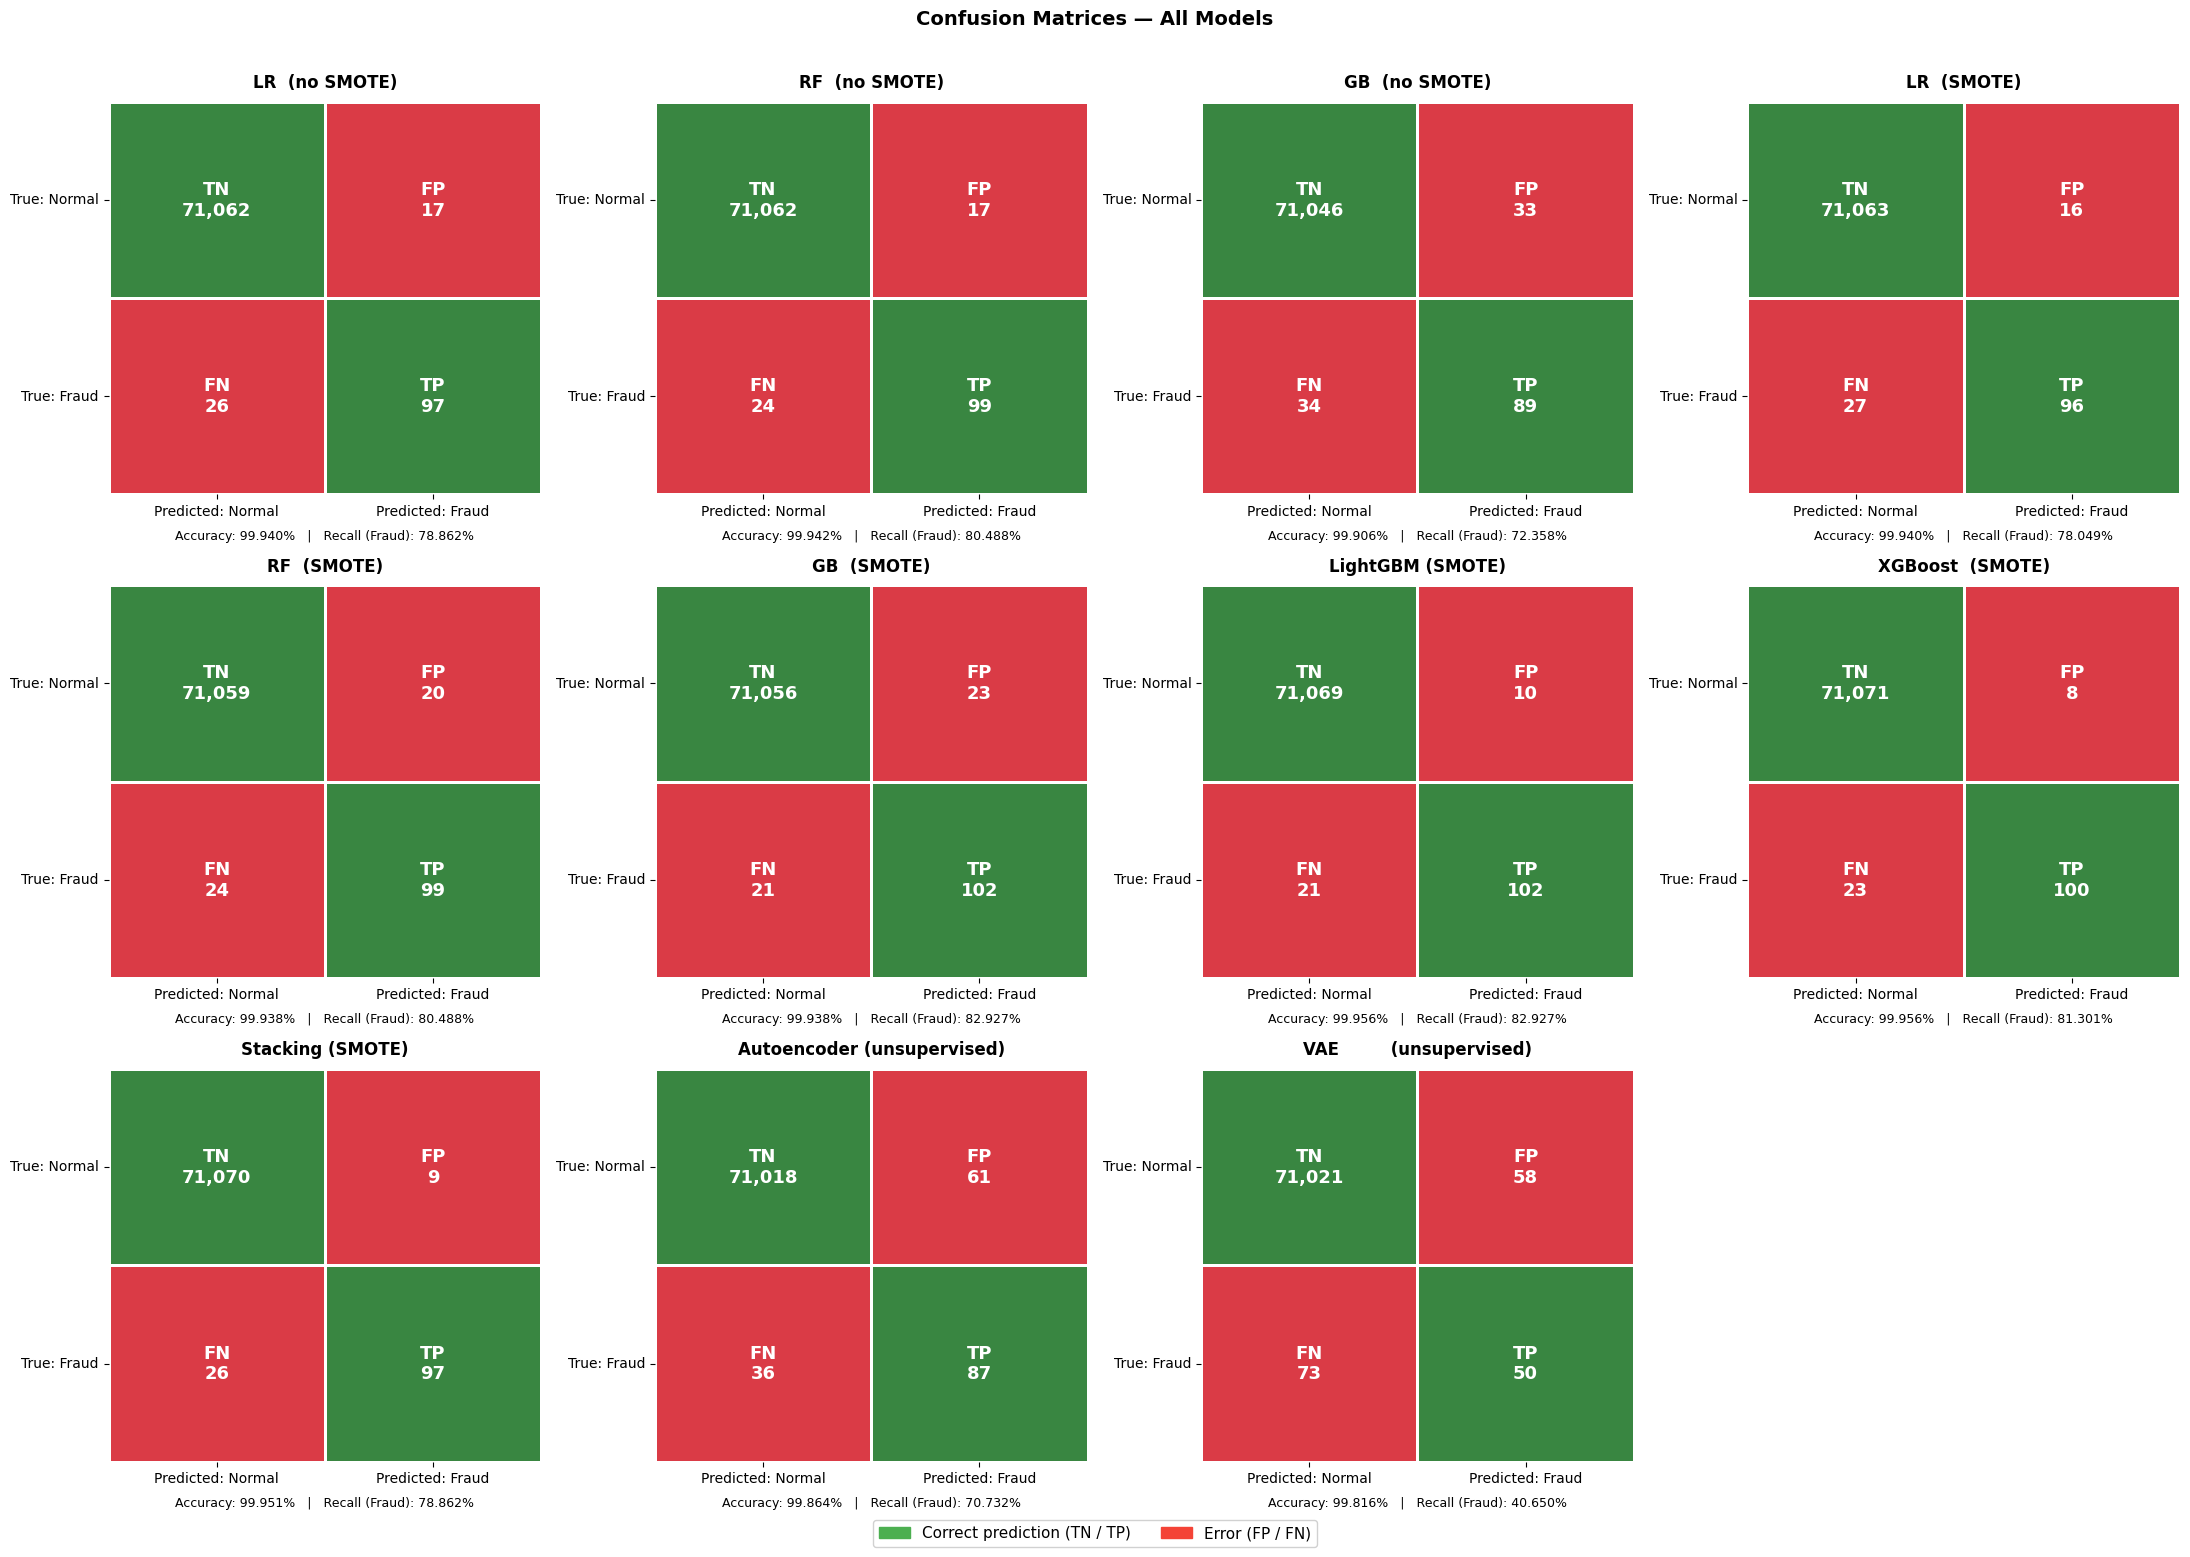

In [37]:
# Confusion matrices: 3 baseline + 6 SMOTE + 1 Autoencoder
ALL_FOR_CM = WITHOUT_SMOTE + WITH_SMOTE + AUTOENCODER

ncols = 4
nrows = -(-len(ALL_FOR_CM) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 5))
axes_flat = axes.flatten()

for ax, (name, score, _) in zip(axes_flat, ALL_FOR_CM):
    plot_confusion(ax, y_test, score, name)

for ax in axes_flat[len(ALL_FOR_CM):]:
    ax.set_visible(False)

fig.suptitle('Confusion Matrices — All Models',
             fontsize=14, fontweight='bold', y=1.01)
correct_patch = mpatches.Patch(color='#4CAF50', label='Correct prediction (TN / TP)')
wrong_patch   = mpatches.Patch(color='#F44336', label='Error (FP / FN)')
fig.legend(handles=[correct_patch, wrong_patch],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02),
           fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

In [38]:
# Classification report for best SMOTE model
best_smote = summary_all[summary_all['Group']=='With SMOTE'].sort_values('PR-AUC', ascending=False).iloc[0]
best_name_sm = best_smote['Model']
best_score_sm = next(s for n, s, _ in WITH_SMOTE if n == best_name_sm)

thr, _, _, _ = best_threshold(y_test, best_score_sm)
pred = (best_score_sm >= thr).astype(int)

print(f'Best SMOTE model: {best_name_sm}')
print(f'PR-AUC: {best_smote["PR-AUC"]}  |  ROC-AUC: {best_smote["ROC-AUC"]}')
print('=' * 55)
print(classification_report(y_test, pred, digits=4, target_names=['Normal','Fraud']))

Best SMOTE model: XGBoost  (SMOTE)
PR-AUC: 0.8639  |  ROC-AUC: 0.9842
              precision    recall  f1-score   support

      Normal     0.9997    0.9999    0.9998     71079
       Fraud     0.9259    0.8130    0.8658       123

    accuracy                         0.9996     71202
   macro avg     0.9628    0.9064    0.9328     71202
weighted avg     0.9995    0.9996    0.9996     71202



## 11. Temporal Split — Train on Day 1, Test on Day 2

> A random stratified split is a common shortcut, but it leaks the future into training.
> In a real fraud-detection system the model is trained on historical data and deployed on
> future transactions — so we should evaluate it the same way.
>
> Here we split the dataset at the **median timestamp**: the first half becomes the training
> set, the second half becomes the test set. We then retrain XGBoost (SMOTE) on this split
> and compare results with the random-split version.


Temporal train:  142,404  |  fraud: 269 (0.1889%)
Temporal test:   142,403   |  fraud: 223 (0.1566%)

XGBoost — Random split   |  ROC-AUC: 0.9842  |  PR-AUC: 0.8639
XGBoost — Temporal split |  ROC-AUC: 0.9684  |  PR-AUC: 0.7784

⚠  The temporal split gives a more honest (usually lower) estimate of real-world performance.


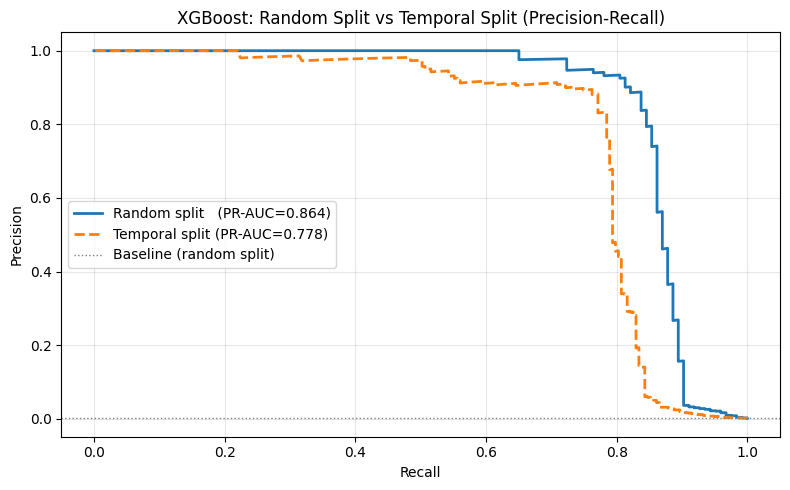

In [ ]:
# Temporal split: first 50% of time - train, last 50% - test
time_threshold = df["Time"].median()
train_t_idx = df[df["Time"] <= time_threshold].index
test_t_idx  = df[df["Time"] >  time_threshold].index

df_train_t = df.loc[train_t_idx].copy()
df_test_t  = df.loc[test_t_idx].copy()

X_train_t = df_train_t.drop(columns=DROP).select_dtypes(include=[np.number]).copy()
y_train_t = df_train_t["Class"].astype(int)
X_test_t  = df_test_t.drop(columns=DROP).select_dtypes(include=[np.number]).copy()
y_test_t  = df_test_t["Class"].astype(int)

shared_t = [c for c in X_train_t.columns if c in X_test_t.columns]
X_train_t = X_train_t[shared_t]
X_test_t  = X_test_t[shared_t]

print(f"Temporal train:  {len(X_train_t):,}  |  fraud: {y_train_t.sum():,} ({y_train_t.mean():.4%})")
print(f"Temporal test:   {len(X_test_t):,}   |  fraud: {y_test_t.sum():,} ({y_test_t.mean():.4%})")

# SMOTE on temporal train
smote_t = SMOTE(k_neighbors=5, random_state=SEED)
X_sm_t, y_sm_t = smote_t.fit_resample(X_train_t, y_train_t)

# Validation split for early stopping
from sklearn.model_selection import train_test_split as tts
X_sm_t_tr, X_sm_t_val, y_sm_t_tr, y_sm_t_val = tts(
    X_sm_t, y_sm_t, test_size=0.1, random_state=SEED)

# Retrain XGBoost on temporal split
from xgboost import XGBClassifier
xgb_time = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=30,
    random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_time.fit(X_sm_t_tr, y_sm_t_tr,
             eval_set=[(X_sm_t_tr, y_sm_t_tr), (X_sm_t_val, y_sm_t_val)],
             verbose=False)

score_xgb_time = xgb_time.predict_proba(X_test_t)[:, 1]

roc_rand = roc_auc_score(y_test,   score_xgb_sm)
pr_rand  = average_precision_score(y_test,   score_xgb_sm)
roc_time = roc_auc_score(y_test_t, score_xgb_time)
pr_time  = average_precision_score(y_test_t, score_xgb_time)

print(f"\nXGBoost — Random split   |  ROC-AUC: {roc_rand:.4f}  |  PR-AUC: {pr_rand:.4f}")
print(f"XGBoost — Temporal split |  ROC-AUC: {roc_time:.4f}  |  PR-AUC: {pr_time:.4f}")
print("\n⚠  The temporal split gives a more honest (usually lower) estimate of real-world performance.")

# Side-by-side PR curves
fig, ax = plt.subplots(figsize=(8, 5))
for score, y, label, ls in [
    (score_xgb_sm,   y_test,   f"Random split   (PR-AUC={pr_rand:.3f})",  "-"),
    (score_xgb_time, y_test_t, f"Temporal split (PR-AUC={pr_time:.3f})", "--"),
]:
    prec, rec, _ = precision_recall_curve(y, score)
    ax.plot(rec, prec, lw=2, ls=ls, label=label)
ax.axhline(y_test.mean(), color="grey", ls=":", lw=1, label="Baseline (random split)")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("XGBoost: Random Split vs Temporal Split (Precision-Recall)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 12. Cost-based Threshold & Threshold Comparison

A fixed threshold of 0.5 ignores business reality. In fraud detection:
- **False Negative (missed fraud):** the bank absorbs the full loss — assume **$500** per case
- **False Positive (false alarm):** customer service cost + cardholder friction — assume **$5** per case

We sweep all thresholds, compute total cost at each one, and find the optimum.
We also build a lookup table: *at which threshold do we catch X% of fraud?*


Optimal cost threshold: 0.013
  TP=109  FP=188  FN=14
  Total cost: $7,940  (FN=$7,000  FP=$940)


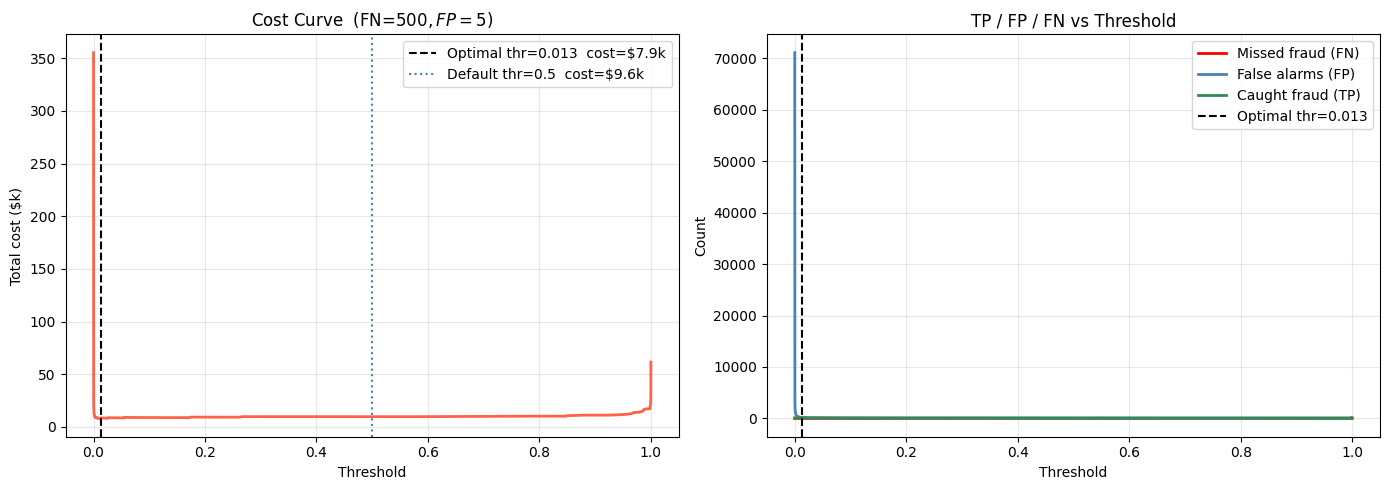


── Threshold Lookup Table ──


,Target Recall,Threshold,TP (caught),FP (alarms),FN (missed),Precision,Total Cost $
0,70%,0.999,87,2,36,0.978,"18,010"
1,80%,0.959,99,7,24,0.934,"12,035"
2,85%,0.262,105,27,18,0.795,"9,135"
3,90%,0.003,111,593,12,0.158,"8,965"
4,95%,0.000,117,5164,6,0.022,"28,820"
5,99%,0.000,122,30909,1,0.004,"155,045"
6,100%,0.000,123,44151,0,0.003,"220,755"


In [ ]:
COST_FN = 500   # missed fraud: bank absorbs transaction
COST_FP = 5     # false alarm: ops cost + customer friction

prec_c, rec_c, thr_c = precision_recall_curve(y_test, score_xgb_sm)
thr_c = np.append(thr_c, 1.0)   # align length

costs, fp_counts, fn_counts, tp_counts = [], [], [], []
for thr in thr_c:
    pred = (score_xgb_sm >= thr).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    costs.append(fn * COST_FN + fp * COST_FP)
    fp_counts.append(fp); fn_counts.append(fn); tp_counts.append(tp)

costs      = np.array(costs)
fp_counts  = np.array(fp_counts)
fn_counts  = np.array(fn_counts)
tp_counts  = np.array(tp_counts)

best_idx  = np.argmin(costs)
best_cost = costs[best_idx]
best_thr_cost = thr_c[best_idx]

print(f"Optimal cost threshold: {best_thr_cost:.3f}")
print(f"  TP={tp_counts[best_idx]}  FP={fp_counts[best_idx]}  FN={fn_counts[best_idx]}")
print(f"  Total cost: ${best_cost:,.0f}  (FN=${fn_counts[best_idx]*COST_FN:,}  FP=${fp_counts[best_idx]*COST_FP:,})")

# Cost curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thr_c, costs / 1000, color='tomato', lw=2)
ax.axvline(best_thr_cost, color='black', ls='--', lw=1.5,
           label=f"Optimal thr={best_thr_cost:.3f}  cost=${best_cost/1000:.1f}k")
ax.axvline(0.5, color='steelblue', ls=':', lw=1.5,
           label=f"Default thr=0.5  cost=${costs[np.searchsorted(thr_c, 0.5)]/1000:.1f}k")
ax.set_xlabel("Threshold"); ax.set_ylabel("Total cost ($k)")
ax.set_title(f"Cost Curve  (FN=${COST_FN}, FP=${COST_FP})")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(thr_c, fn_counts, color='red',       lw=2, label='Missed fraud (FN)')
ax.plot(thr_c, fp_counts, color='steelblue', lw=2, label='False alarms (FP)')
ax.plot(thr_c, tp_counts, color='seagreen',  lw=2, label='Caught fraud (TP)')
ax.axvline(best_thr_cost, color='black', ls='--', lw=1.5, label=f"Optimal thr={best_thr_cost:.3f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Count")
ax.set_title("TP / FP / FN vs Threshold")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Threshold comparison table
print("\n── Threshold Lookup Table ──")
n_fraud_test = int(y_test.sum())
targets = [0.70, 0.80, 0.85, 0.90, 0.95, 0.99, 1.00]
rows = []
for target_recall in targets:
    # find smallest threshold that achieves at least target_recall
    mask = rec_c[:-1] >= target_recall
    if not mask.any():
        thr_sel = thr_c[0]
    else:
        thr_sel = thr_c[:-1][mask][-1]   # highest threshold still achieving recall
    pred = (score_xgb_sm >= thr_sel).astype(int)
    tp_s = int(((pred==1)&(y_test==1)).sum())
    fp_s = int(((pred==1)&(y_test==0)).sum())
    fn_s = int(((pred==0)&(y_test==1)).sum())
    prec_s = tp_s / (tp_s + fp_s) if (tp_s + fp_s) > 0 else 0
    cost_s = fn_s * COST_FN + fp_s * COST_FP
    rows.append({
        "Target Recall": f"{target_recall:.0%}",
        "Threshold":     f"{thr_sel:.3f}",
        "TP (caught)":   tp_s,
        "FP (alarms)":   fp_s,
        "FN (missed)":   fn_s,
        "Precision":     f"{prec_s:.3f}",
        "Total Cost $":  f"{cost_s:,}",
    })
tbl = pd.DataFrame(rows)
display(tbl.style.set_caption("Threshold Lookup: catching X% of fraud and its cost"))


## 13. Probability Calibration

A model that says *p = 0.9* should be right about 90% of the time.
This property is called **calibration**. A well-calibrated model lets you set thresholds
based on cost reasoning — which we did above. A poorly calibrated model gives probabilities
that are systematically too high or too low.

We use a **reliability diagram (calibration curve)** with 10 bins:
each bin groups predictions by score, and we check whether the fraction of actual fraud
matches the predicted probability.


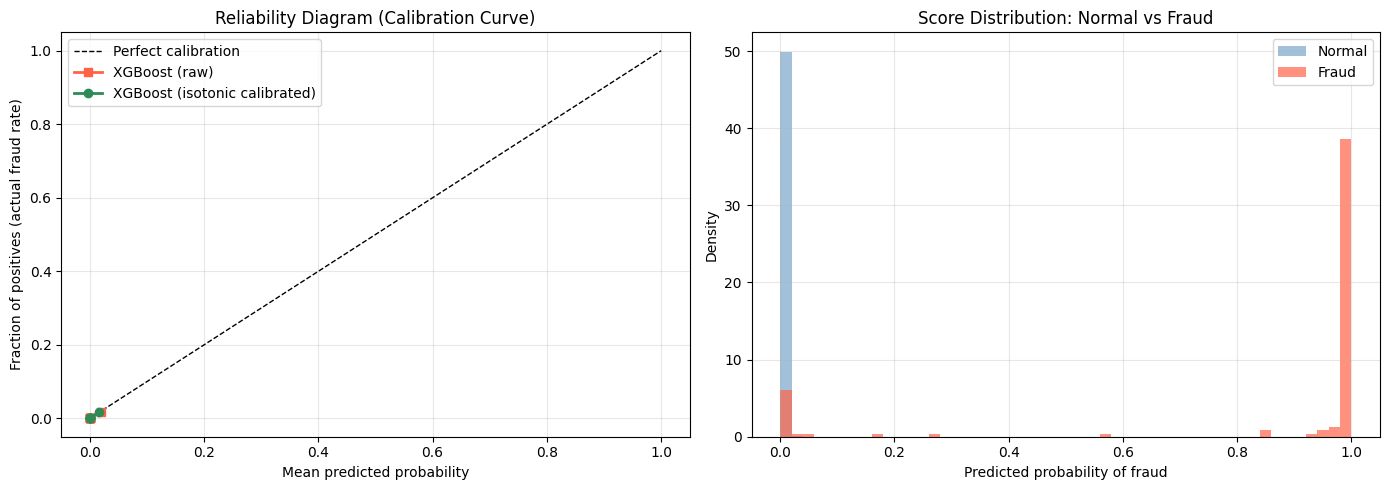

Brier Score (raw):        0.00052  (lower = better calibration)
Brier Score (calibrated): 0.00038

Note: Brier score < 0.01 on this dataset is typical due to extreme class imbalance.


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

# Raw XGBoost calibration
frac_pos_xgb, mean_pred_xgb = calibration_curve(
    y_test, score_xgb_sm, n_bins=10, strategy='quantile')

# Isotonic calibration (fits directly on predicted scores)
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(score_xgb_sm, y_test)
score_xgb_cal = iso_reg.predict(score_xgb_sm)
frac_pos_cal, mean_pred_cal = calibration_curve(
    y_test, score_xgb_cal, n_bins=10, strategy='quantile')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.plot(mean_pred_xgb, frac_pos_xgb, 's-', color='tomato',   lw=2, label='XGBoost (raw)')
ax.plot(mean_pred_cal, frac_pos_cal,  'o-', color='seagreen', lw=2, label='XGBoost (isotonic calibrated)')
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (actual fraud rate)")
ax.set_title("Reliability Diagram (Calibration Curve)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(score_xgb_sm[y_test == 0], bins=50, alpha=0.5,
        color='steelblue', label='Normal', density=True)
ax.hist(score_xgb_sm[y_test == 1], bins=50, alpha=0.7,
        color='tomato',    label='Fraud',  density=True)
ax.set_xlabel("Predicted probability of fraud")
ax.set_ylabel("Density")
ax.set_title("Score Distribution: Normal vs Fraud")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Calibration summary
brier_raw = brier_score_loss(y_test, score_xgb_sm)
brier_cal = brier_score_loss(y_test, score_xgb_cal)
print(f"Brier Score (raw):        {brier_raw:.5f}  (lower = better calibration)")
print(f"Brier Score (calibrated): {brier_cal:.5f}")
print(f"\nNote: Brier score < 0.01 on this dataset is typical due to extreme class imbalance.")

## 14. SHAP Analysis — Why Did XGBoost Flag This Transaction?

**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution score
for each individual prediction. A positive SHAP value pushes the prediction toward fraud;
negative pushes it toward normal.

This allows us to answer: *which of V1–V28 (and engineered features) matter most,
and how do they influence the fraud score?*


Computing SHAP values for XGBoost (SMOTE) on test set...
SHAP values shape: (71202, 38)


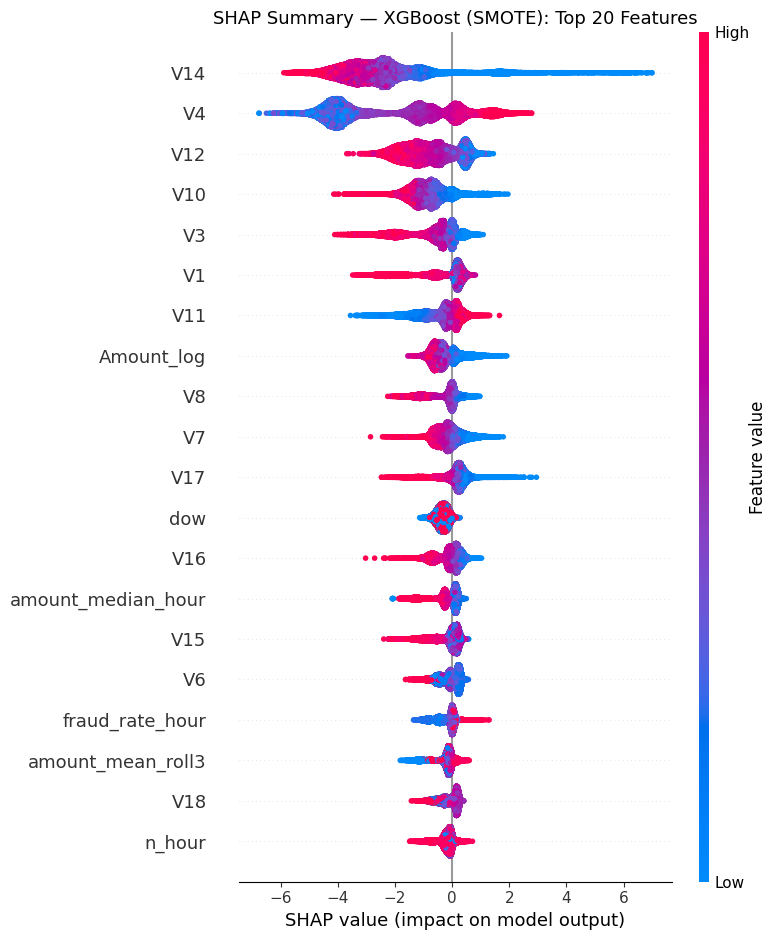

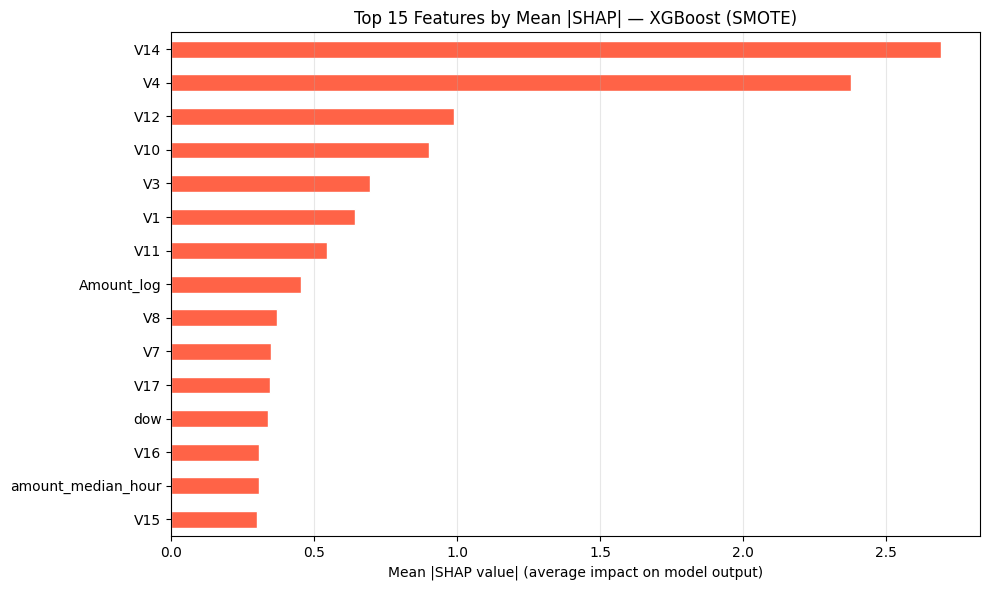


Top 10 features by mean |SHAP|:
V14           2.693481
V4            2.378421
V12           0.988890
V10           0.901229
V3            0.695823
V1            0.643351
V11           0.543159
Amount_log    0.452230
V8            0.370463
V7            0.349344


In [ ]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

print("Computing SHAP values for XGBoost (SMOTE) on test set...")
explainer   = shap.TreeExplainer(xgb_sm)
shap_values = explainer.shap_values(X_test)   # shape (n_test, n_features)

print(f"SHAP values shape: {shap_values.shape}")

# Global feature importance — beeswarm plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot",
                  max_display=20, show=False)
plt.title("SHAP Summary — XGBoost (SMOTE): Top 20 Features", fontsize=13)
plt.tight_layout(); plt.show()

# Mean |SHAP| bar chart
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_importance = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_importance.head(15).plot.barh(ax=ax, color='tomato', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value| (average impact on model output)")
ax.set_title("Top 15 Features by Mean |SHAP| — XGBoost (SMOTE)")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print("\nTop 10 features by mean |SHAP|:")
print(feat_importance.head(10).to_string())


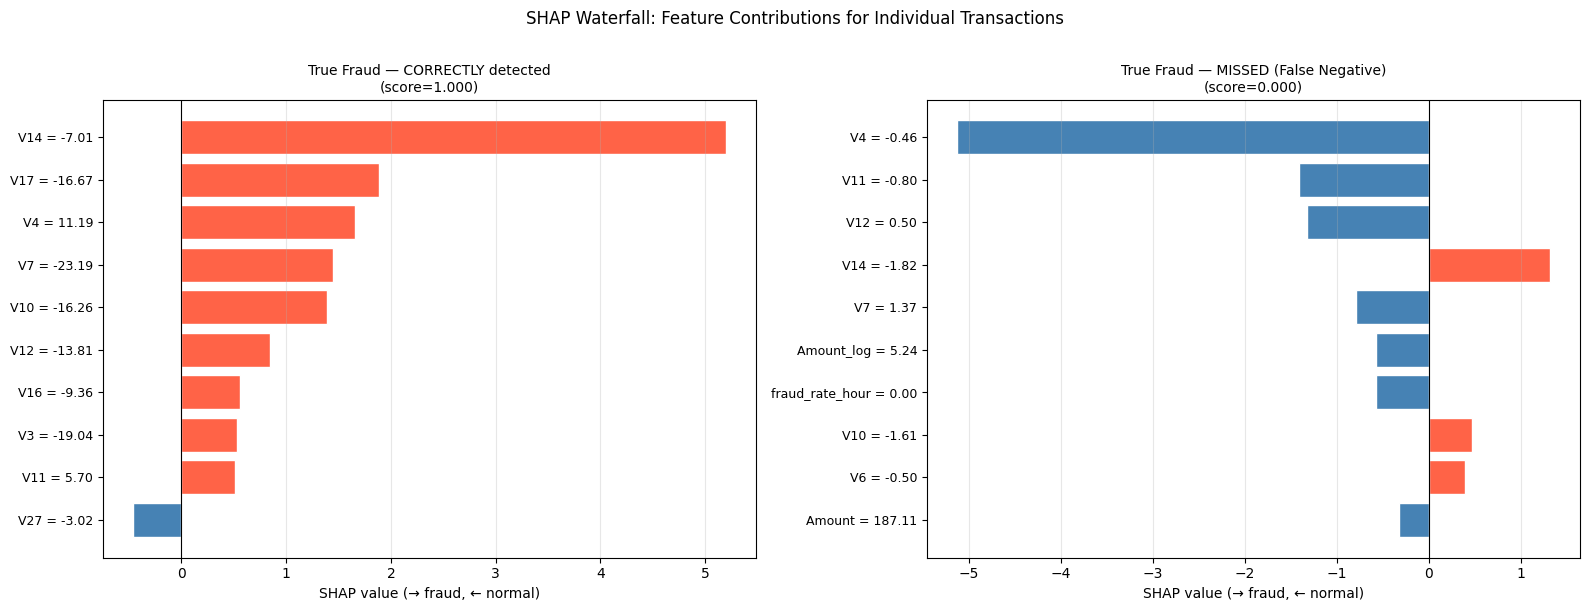

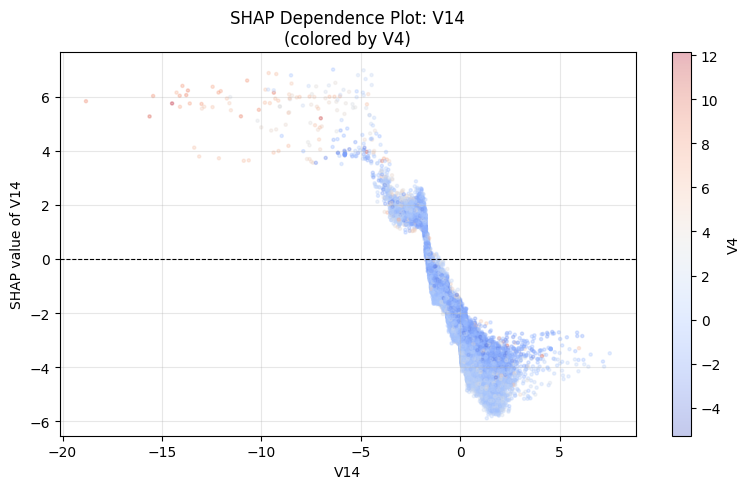

In [ ]:
# Waterfall plot for a single fraud transaction
fraud_indices   = np.where(y_test.values == 1)[0]
normal_indices  = np.where(y_test.values == 0)[0]

# Pick the highest-confidence fraud (highest score)
top_fraud_idx   = fraud_indices[np.argmax(score_xgb_sm[fraud_indices])]
# Pick a false negative (missed fraud with lowest score)
fn_mask = (y_test.values == 1) & (score_xgb_sm < 0.5)
fn_indices = np.where(fn_mask)[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, idx, title in [
    (axes[0], top_fraud_idx,
     f"True Fraud — CORRECTLY detected\n(score={score_xgb_sm[top_fraud_idx]:.3f})"),
    (axes[1], fn_indices[0] if len(fn_indices) > 0 else fraud_indices[-1],
     f"True Fraud — MISSED (False Negative)\n(score={score_xgb_sm[fn_indices[0] if len(fn_indices)>0 else fraud_indices[-1]]:.3f})"),
]:
    shap_row = shap_values[idx]
    feat_vals = X_test.iloc[idx]
    
    # Top 10 contributors
    order = np.argsort(np.abs(shap_row))[::-1][:10]
    top_names  = X_test.columns[order]
    top_shap   = shap_row[order]
    top_vals   = feat_vals.values[order]
    
    colors = ['tomato' if s > 0 else 'steelblue' for s in top_shap]
    bars = ax.barh(range(len(top_names)), top_shap, color=colors, edgecolor='white')
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels([f"{n} = {v:.2f}" for n, v in zip(top_names, top_vals)], fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel("SHAP value (→ fraud, ← normal)")
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle("SHAP Waterfall: Feature Contributions for Individual Transactions", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

# SHAP dependence plot for top feature
top_feat = feat_importance.index[0]
second_feat = feat_importance.index[1]

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(X_test[top_feat], shap_values[:, X_test.columns.get_loc(top_feat)],
                c=X_test[second_feat], cmap='coolwarm', alpha=0.3, s=5)
plt.colorbar(sc, ax=ax, label=second_feat)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel(top_feat)
ax.set_ylabel(f"SHAP value of {top_feat}")
ax.set_title(f"SHAP Dependence Plot: {top_feat}\n(colored by {second_feat})")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
